# 05 — Final Merge, Deduplication, Outlier Handling & Standardization (Team 5)

## Responsibility
This notebook is the final stage of Phase 1. It must only be run AFTER all four
team notebooks (01–04) have been completed and verified.

## How to Use
1. Copy the complete code from notebooks 01, 02, 03, and 04 into the designated
   sections below (marked with banners).
2. Each section produces its respective df_team1 / df_team2 / df_team3 / df_team4.
3. This notebook then merges them, deduplicates, handles outliers, standardizes, and removes useless rows/columns.
4. A complete checkup of analytical statistics is run (correlation maps, barplots, anything that helps us understand the data ...).

## What is Expected as Output
- A single DataFrame with ALL columns from teams 1–4 merged column-wise
- Zero duplicate rows
- Outliers detected and handled (capping at 1.5×IQR or removal or ... — team decides and justifies)
- All columns standardized: mean=0, std=1 using StandardScaler
- Zero null values
- Zero non-numeric columns
- Saved to data/processed_dataset.csv

---

> ## ⚠️ READ THIS BEFORE YOU WRITE A SINGLE LINE OF CODE ⚠️
>
> ### The code below is a PLACEHOLDER — it is NOT the final solution.
>
> The cells in this notebook show **one possible way** to process the assigned columns. You are **not** required to follow this approach. You may completely replace it with your own method if you believe yours is better suited to the data.
>
> ### What IS required — without exception:
>
> **Every code cell must be accompanied by a markdown cell that explains:**
> 1. **What you did** — describe the operation in plain language.
> 2. **Why you did it** — justify the choice. Why did you think this specific approach would work? What problem does it solve? Why this method and not another?
>
> A notebook that only contains code — or markdown cells that just repeat the code in words — will **not** be accepted.
>
> **Not acceptable:** `## Step 2` or `# fill nulls`
>
> **Acceptable:** *"We imputed missing values in `Kilometre` with the median rather than the mean because the column is heavily right-skewed (a small number of very high-mileage listings would pull the mean upward, misrepresenting the majority of vehicles). The median is robust to those outliers and better reflects a typical listing."*
>
> Document every decision. If you tried an approach and abandoned it, explain why.

---

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

RAW_URL = "https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/raw_dataset.csv"
df_full = pd.read_csv(RAW_URL)
print(f"Loaded dataset: {df_full.shape}")

Loaded dataset: (3424, 45)


In [93]:
# ════════════════════════════════════════════════════════════
# PASTE TEAM 1 CODE HERE (from 01_core_numeric.ipynb)
# Expected output variable: df_team1
# ════════════════════════════════════════════════════════════


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

sns.set_theme(style="whitegrid")

# Isolate Team 1 columns
MY_COLUMNS = [
    'Fiyat', 'Yıl', 'Kilometre', 'İlan Tarihi',
    'Ortalama Kasko', 'Ortalama Trafik Sigortası',
    'Üretim Yılı (İlk/Son)', 'Silindir Sayısı',
    'Koltuk Sayısı', 'Bagaj Hacmi', 'Yakıt Deposu'
]
df = df_full[MY_COLUMNS].copy()

#Step 2 (data cleaning and advanced imputation)

# 1. Standardize Price (Fiyat) - Removing currency and formatting
df['Fiyat'] = df['Fiyat'].astype(str).str.replace('TL', '', regex=False).str.replace('.', '', regex=False).str.strip().astype(int)

# 2. Üretim Yılı Logic: Midpoint of the Range
# Instead of taking just the first year, we average the start and end years to preserve generation data
def get_year_midpoint(year_str):
    years = pd.Series(str(year_str)).str.extractall(r'(\d{4})')[0].astype(float)
    if not years.empty:
        return years.mean()
    return np.nan

df['Üretim Yılı (İlk/Son)'] = df['Üretim Yılı (İlk/Son)'].apply(get_year_midpoint)

# 3. Strip units and handle decimals for numeric columns
# We leave them as NaN here so the Iterative Imputer can "predict" them later
for col in ['Kilometre', 'Ortalama Kasko', 'Ortalama Trafik Sigortası']:
    df[col] = (df[col].astype(str)
               .str.replace(' km', '', regex=False)
               .str.replace('TL', '', regex=False)
               .str.replace('.', '', regex=False)
               .str.strip()
               .replace('nan', np.nan))
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['Bagaj Hacmi', 'Yakıt Deposu']:
    df[col] = (df[col].astype(str)
               .str.replace(' lt', '', regex=False)
               .str.replace(',', '.', regex=False) # Turkish decimal comma fix
               .str.strip()
               .replace('nan', np.nan))
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Clean Date (İlan Tarihi) - Conversion to linear time
df['İlan Tarihi'] = pd.to_datetime(df['İlan Tarihi'], dayfirst=True, errors='coerce', format='mixed')
min_date = df['İlan Tarihi'].min()
df['İlan Tarihi'] = (df['İlan Tarihi'] - min_date).dt.days

# 5. Multivariate Iterative Imputation
# Estimates missing values based on correlations between all numeric features
imputer = IterativeImputer(random_state=42, max_iter=10)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# 6. Precision Rounding & Casting
# Convert business-critical values to integers for a cleaner dataset
df_imputed['Fiyat'] = df_imputed['Fiyat'].round().astype(int)
df_imputed['Kilometre'] = df_imputed['Kilometre'].round().astype(int)

# Round discrete car specs to nearest whole number
for col in ['Yıl', 'Silindir Sayısı', 'Koltuk Sayısı', 'İlan Tarihi']:
    df_imputed[col] = df_imputed[col].round().astype(int)

# Round technical estimations to 2 decimal places to maintain imputer signal
float_cols = ['Ortalama Kasko', 'Ortalama Trafik Sigortası', 'Üretim Yılı (İlk/Son)', 'Bagaj Hacmi', 'Yakıt Deposu']
df_imputed[float_cols] = df_imputed[float_cols].round(2)

df = df_imputed


#Final

df_team1 = df.copy()



In [94]:


# ════════════════════════════════════════════════════════════
# PASTE TEAM 2 CODE HERE (from 02_categorical_encoding.ipynb)
# Expected output variable: df_team2
# ════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder

#Step 1 (Selecting columns)

MY_COLUMNS = ['Marka', 'Seri', 'Model', 'Vites Tipi', 'Yakıt Tipi', 'Kasa Tipi', 'Renk', 'Çekiş', 'Kimden', 'Sınıfı']

df = df_full[MY_COLUMNS].copy()

# Keep price as the target for target-encoding steps
if 'Fiyat' in df_full.columns:
    y = df_full['Fiyat'].copy()
else:
    y = None
    print("⚠️  'Fiyat' column not found — target encoding will use row index rank as proxy.")

#step 2
# change all the - and SUV color to null values
df.replace('-', np.nan, inplace=True)
df.loc[df['Renk'] == 'SUV', 'Renk'] = np.nan

eda = pd.DataFrame({
    'cardinality': df.nunique(),
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'sample_values': [df[c].dropna().unique()[:5].tolist() for c in df.columns]
})


#Step3


from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

def knn_impute(target_col, cat_features, num_features=['Yıl', 'Motor Hacmi', 'Motor Gücü'], df=df, df_full=df_full, n_neighbors=5):
    """Impute missing values in target_col using kNN with proper mixed-distance handling."""
    null_count = df[target_col].isna().sum()
    if null_count == 0:
        return

    # Build feature matrix
    cat_df = pd.DataFrame({
        col: (df[col] if col in df.columns else df_full[col])
        for col in cat_features
    }).astype(str).fillna('Unknown')
    knn_cat = pd.get_dummies(cat_df)

    num_raw = pd.DataFrame({
        col: pd.to_numeric(
            (df[col] if col in df.columns else df_full[col])
            .astype(str).str.extract(r'([\d.]+)')[0],
            errors='coerce'
        ) for col in num_features
    })
    num_scaled = pd.DataFrame(
        MinMaxScaler().fit_transform(num_raw.fillna(num_raw.median())),
        columns=num_features, index=df.index
    )

    X_all = pd.concat([knn_cat, num_scaled], axis=1)
    known, unknown = df[target_col].notna(), df[target_col].isna()

    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric='hamming')
    knn.fit(X_all.loc[known], df.loc[known, target_col])
    df.loc[unknown, target_col] = knn.predict(X_all.loc[unknown])


    knn_impute('Renk', cat_features=['Marka', 'Seri', 'Model', 'Kasa Tipi', 'Yakıt Tipi'])
    knn_impute('Kasa Tipi', cat_features=['Marka', 'Seri', 'Model', 'Renk', 'Yakıt Tipi', 'Vites Tipi'])
    knn_impute('Çekiş', cat_features=['Marka', 'Seri', 'Model', 'Kasa Tipi', 'Renk', 'Yakıt Tipi'])
    knn_impute('Sınıfı', cat_features=['Marka', 'Seri', 'Model', 'Kasa Tipi', 'Çekiş', 'Vites Tipi', 'Yakıt Tipi', 'Kimden'])


    #Step 4 (binary ones)

    df['is_Nissan'] = (df['Marka'] == 'Nissan').astype(int)
    df.drop(columns=['Marka'], inplace=True)

    #Step 5 (ordinal ones)


vites_order = [['Düz', 'Yarı Otomatik', 'Otomatik']]
oe = OrdinalEncoder(categories=vites_order,
                    handle_unknown='use_encoded_value',
                    unknown_value=-1)
df['Vites Tipi'] = oe.fit_transform(df[['Vites Tipi']]).astype(int)


  # Step 6
OHE_COLS = ['Kimden', 'Yakıt Tipi', 'Kasa Tipi', 'Çekiş', 'Renk']

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe_array = ohe.fit_transform(df[OHE_COLS])
ohe_cols  = ohe.get_feature_names_out(OHE_COLS)

df = df.drop(columns=OHE_COLS).join(
    pd.DataFrame(ohe_array, columns=ohe_cols, index=df.index)
)


#Step 7


TARGET_ENC_COLS = ['Seri', 'Model', 'Sınıfı']

# Parse price from df_full for use as target signal
y_enc = (
    df_full['Fiyat'].astype(str).str.strip()
    .str.replace(r'[^\d]', '', regex=True)
    .pipe(pd.to_numeric, errors='coerce')
)
y_enc = y_enc.fillna(y_enc.median())

global_mean = y_enc.mean()
for col in TARGET_ENC_COLS:
    means = y_enc.groupby(df[col].values).mean()
    df[col] = df[col].map(means).fillna(global_mean)


#FINALL
df_team2 = df.copy()




In [95]:
# ════════════════════════════════════════════════════════════
# PASTE TEAM 3 CODE HERE (from 03_paint_damage.ipynb)
# Expected output variable: df_team3
# ════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

MY_COLUMNS = ['Boya-değişen', 'Orjinal', 'Lokal boyalı', 'Boyalı', 'Değişmiş', 'Belirtilmemiş']
df = df_full[MY_COLUMNS].copy().fillna('-')

#Step 1
def extract_regex_counts(text):
    # Sonuçları tutacak sözlük (başlangıçta hepsi 0)
    counts = {'reg_degisen': 0, 'reg_boyali': 0, 'reg_lokal': 0}

    # Metni küçük harfe çevir (büyük/küçük harf sorununu önlemek için)
    text_lower = str(text).lower()

    # Özel durumlar (anlamsız veya boş veriler)
    if text in ['-', 'Belirtilmemiş', 'Tamamı orjinal', '']:
        return pd.Series(counts)

    # Tüm parçalar boyalıysa
    if 'tamamı boyalı' in text_lower:
        counts['reg_boyali'] = 13
        return pd.Series(counts)

    # Tüm parçalar lokal boyalıysa
    if 'tamamı lokal boyalı' in text_lower:
        counts['reg_lokal'] = 13
        return pd.Series(counts)

    # findall kullanarak TÜM eşleşmeleri yakala
    deg_list = re.findall(r'(\d+)\s*(değişen|degisen)', text_lower)
    lok_list = re.findall(r'(\d+)\s*lokal', text_lower)
    boy_list = re.findall(r'(\d+)\s*(boyalı|boyali)', text_lower)

    # Bulunan tüm değerleri topla
    counts['reg_degisen'] = sum(int(x[0]) for x in deg_list)
    counts['reg_lokal'] = sum(int(x) for x in lok_list)
    counts['reg_boyali'] = sum(int(x[0]) for x in boy_list)

    # Sonucu pandas Series olarak döndür
    return pd.Series(counts)

# Fonksiyonu uygula ve geçici sütunlar olarak ekle
regex_df = df['Boya-değişen'].apply(extract_regex_counts)
df = pd.concat([df, regex_df], axis=1)


#Step 2
# 13 Temel Kaporta Parçası
CAR_PARTS = [
    'sağ arka çamurluk', 'sol arka çamurluk', 'sağ ön çamurluk', 'sol ön çamurluk',
    'sağ arka kapı', 'sol arka kapı', 'sağ ön kapı', 'sol ön kapı',
    'arka kaput', 'motor kaputu', 'ön tampon', 'arka tampon', 'tavan'
]

def count_keywords(text):
    if text in ['-', '', '0', 'tamamı orjinal', 'belirtilmemiş']:
        return 0
    text_lower = str(text).lower()
    # Kelimeler arasındaki boşlukları değil, listedeki spesifik parçaları sayıyoruz
    return sum(1 for part in CAR_PARTS if part in text_lower)

# Parça isimlerini sütunlardan say
kw_boyali = df['Boyalı'].apply(count_keywords)
kw_lokal = df['Lokal boyalı'].apply(count_keywords)
kw_degisen = df['Değişmiş'].apply(count_keywords)

# İSTENEN TEMEL SÜTUNLAR (Çift sayımı önleyerek)
# Boyalı parçalar (Normal + Lokal)
df['total_painted_parts'] = np.maximum(df['reg_boyali'], kw_boyali) + np.maximum(df['reg_lokal'], kw_lokal)

# Değişen parçalar
df['total_changed_parts'] = np.maximum(df['reg_degisen'], kw_degisen)

# Orjinal mi?
df['is_fully_original'] = (df['Boya-değişen'].str.strip().str.lower() == 'tamamı orjinal').astype(int)

# Boya-değişen sütununda bahsedilen toplam parça
df['Boya-değişen_count'] = df['reg_degisen'] + df['reg_boyali'] + df['reg_lokal']

# Genel hasar skoru (Tüm boyalı ve değişenlerin toplamı)
df['paint_damage_score'] = df['total_painted_parts'] + df['total_changed_parts']


#Step3


# --- Kullanıcı Davranışı ve Tembel Satıcı Analizi (User Behavior Analysis) ---

# 1. Tüm detaylı sütunlardaki toplam "isim" sayısını hesaplayalım
kw_total = kw_boyali + kw_lokal + kw_degisen

# 2. İki sütun arasındaki tam eşleşme (Boya-değişen_count ve paint_damage_score)
eslesme_orani = (df['Boya-değişen_count'] == df['paint_damage_score']).mean() * 100

# 3. "Tembel Satıcı" (Lazy Dealer) Tespiti:
# Özet sütununa hasar sayısı yazmış (>0) AMA detay sütunlarında HİÇ parça seçmemiş (==0)
lazy_dealers_count = ((df['Boya-değişen_count'] > 0) & (kw_total == 0)).sum()

# Toplam hasarlı araç sayısı (herhangi bir hasarı olanlar)
total_damaged_cars = (df['paint_damage_score'] > 0).sum()

# Tembel satıcıların tüm hasarlı araçlar içindeki yüzdesi
lazy_ratio = (lazy_dealers_count / total_damaged_cars) * 100 if total_damaged_cars > 0 else 0


#STEP4

def get_part_status(row, part):
    # En ağır hasardan en hafife doğru kontrol ediyoruz
    if part in str(row['Değişmiş']).lower():
        return 3
    elif part in str(row['Boyalı']).lower():
        return 2
    elif part in str(row['Lokal boyalı']).lower() or part in str(row['Belirtilmemiş']).lower():
        return 1
    else:
        return 0

# Her parça için durum sütunu oluştur
status_cols = []
for part in CAR_PARTS:
    col_name = f"{part.replace(' ', '_')}_durumu"
    status_cols.append(col_name)
    df[col_name] = df.apply(lambda row: get_part_status(row, part), axis=1)

# Orijinal metin sütunlarını at, sadece üretilen sayısal özellikleri sakla
FINAL_COLUMNS = [
    'total_painted_parts', 'total_changed_parts', 'is_fully_original',
     'paint_damage_score'
] + status_cols

#FINALLL

df_team3 = df[FINAL_COLUMNS].copy()

In [96]:
# ════════════════════════════════════════════════════════════
# PASTE TEAM 4 CODE HERE (from 04_technical_specs.ipynb)
# Expected output variable: df_team4
# ════════════════════════════════════════════════════════════



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


MY_COLUMNS = [
    'Motor Hacmi', 'Motor Gücü',
    'Ort. Yakıt Tüketimi', 'Ortalama Yakıt Tüketimi',
    'Şehir İçi Yakıt Tüketimi', 'Şehir Dışı Yakıt Tüketimi',
    'Tork', 'Maksimum Güç', 'Minimum Güç',
    'Hızlanma (0-100)', 'Maksimum Hız',
    'Uzunluk', 'Genişlik', 'Yükseklik',
    'Ağırlık', 'Boş Ağırlığı', 'Aks Aralığı', 'Ön Lastik'
]

GROUP_COLS = ['Marka', 'Seri', 'Model', 'Yıl', 'Vites Tipi', 'Kasa Tipi']
df = df_full[MY_COLUMNS + GROUP_COLS].copy()


#STEP 1
# Helper: parse a range string 'a - b ' → midpoint float, or a single value → float
def parse_range_midpoint(series, strip_patterns):
    s = series.astype(str).str.strip()
    for pat in strip_patterns:
        s = s.str.replace(pat, '', regex=False, case=False).str.strip()
    # Replace comma decimal separators with dots
    s = s.str.replace(',', '.', regex=False)
    # Detect range pattern 'low - high'
    is_range = s.str.contains(r'^\d[\.\d]*\s*-\s*\d', regex=True, na=False)
    result = pd.to_numeric(s.where(~is_range), errors='coerce')
    # For range rows, extract low and high and take midpoint
    parts = s[is_range].str.extract(r'([\d\.]+)\s*-\s*([\d\.]+)')
    if not parts.empty:
        midpoints = (pd.to_numeric(parts[0], errors='coerce') +
                     pd.to_numeric(parts[1], errors='coerce')) / 2
        result[is_range] = midpoints
    return result

    #STEP 2

def smart_fill(df, col):
    """
    Implements your 6-level Hierarchy:
    Specific -> Generation -> Year Match -> Model Match -> Series Match -> Global
    """
    # Level 1: Exact Match (Everything)
    df[col] = df[col].fillna(df.groupby(['Marka', 'Seri', 'Model', 'Yıl', 'Vites Tipi', 'Kasa Tipi'])[col].transform('median'))

    # Level 2: Same Spec, Different Year (Mechanical/Physical Twin)
    df[col] = df[col].fillna(df.groupby(['Marka', 'Seri', 'Model', 'Vites Tipi', 'Kasa Tipi'])[col].transform('median'))

    # Level 3: Model & Year
    df[col] = df[col].fillna(df.groupby(['Marka', 'Seri', 'Model', 'Yıl'])[col].transform('median'))

    # Level 4: Model Match
    df[col] = df[col].fillna(df.groupby(['Marka', 'Seri', 'Model'])[col].transform('median'))

    # Level 5: Series Match (Broad Family)
    df[col] = df[col].fillna(df.groupby(['Marka', 'Seri'])[col].transform('median'))

    # Level 6: Global Median (Final Safety Net)
    df[col] = df[col].fillna(df[col].median())

    return df[col]


    #STEP 3

 # Motor Hacmi
df['Motor Hacmi'] = parse_range_midpoint(df['Motor Hacmi'], [' cm3', 'cm3', ' cc', 'cc'])
df['Motor Hacmi'] = smart_fill(df, 'Motor Hacmi')

# Motor Gücü
df['Motor Gücü'] = parse_range_midpoint(df['Motor Gücü'], [' HP', 'HP', ' hp', 'hp'])
df['Motor Gücü'] = smart_fill(df, 'Motor Gücü')


# Clean fuel consumption columns: strip ' lt', replace comma decimal separator
for col in ['Ort. Yakıt Tüketimi', 'Ortalama Yakıt Tüketimi',
            'Şehir İçi Yakıt Tüketimi', 'Şehir Dışı Yakıt Tüketimi']:
    df[col] = df[col].astype(str).str.replace(' lt', '', regex=False).str.replace(',', '.', regex=False).str.strip().replace('nan', np.nan)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = smart_fill(df, col)


# Clean Tork: strip ' nm'
df['Tork'] = df['Tork'].astype(str).str.replace(' nm', '', regex=False, case=False).str.strip().replace('nan', np.nan)
df['Tork'] = pd.to_numeric(df['Tork'], errors='coerce')
df['Tork'] = smart_fill(df, 'Tork')


# Clean Maksimum Güç and Minimum Güç: strip ' rpm'
for col in ['Maksimum Güç', 'Minimum Güç']:
    df[col] = df[col].astype(str).str.replace(' rpm', '', regex=False, case=False).str.strip().replace('nan', np.nan)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = smart_fill(df, col)


# Clean Hızlanma (0-100): strip ' sn', replace comma with dot
df['Hızlanma (0-100)'] = df['Hızlanma (0-100)'].astype(str).str.replace(' sn', '', regex=False).str.replace(',', '.', regex=False).str.strip().replace('nan', np.nan)
df['Hızlanma (0-100)'] = pd.to_numeric(df['Hızlanma (0-100)'], errors='coerce')
df['Hızlanma (0-100)'] = smart_fill(df, 'Hızlanma (0-100)')


# Clean Maksimum Hız: strip ' km/s'
df['Maksimum Hız'] = df['Maksimum Hız'].astype(str).str.replace(' km/s', '', regex=False).str.strip().replace('nan', np.nan)
df['Maksimum Hız'] = pd.to_numeric(df['Maksimum Hız'], errors='coerce')
df['Maksimum Hız'] = smart_fill(df, 'Maksimum Hız')

# Clean dimension columns: strip ' mm'
for col in ['Uzunluk', 'Genişlik', 'Yükseklik', 'Aks Aralığı']:
    df[col] = df[col].astype(str).str.replace(' mm', '', regex=False).str.strip().replace('nan', np.nan)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = smart_fill(df, col)

# Clean weight columns: strip ' kg'
for col in ['Ağırlık', 'Boş Ağırlığı']:
    df[col] = df[col].astype(str).str.replace(' kg', '', regex=False).str.strip().replace('nan', np.nan)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = smart_fill(df, col)


# Clean Ön Lastik: extract rim diameter from tire size strings like '225/45 R19' → Jant Boyutu
df['Jant Boyutu'] = df['Ön Lastik'].astype(str).str.extract(r'R(\d+)')[0]
df['Jant Boyutu'] = pd.to_numeric(df['Jant Boyutu'], errors='coerce')
df['Jant Boyutu'] = smart_fill(df, 'Jant Boyutu').astype(int)
df.drop(columns=['Ön Lastik'], inplace=True)


#FINALL

# --- Final Step: Clean Output ---
from google.colab import files

# 1. Define the redundant column to drop
# We choose 'Ortalama Yakıt Tüketimi' to drop, keeping 'Ort. Yakıt Tüketimi'
redundant_cols = ['Ortalama Yakıt Tüketimi']

# 2. Identify all columns to drop (IDs, original tire string, and the duplicate fuel column)
drop_list = [c for c in GROUP_COLS + ['Ön Lastik'] + redundant_cols if c in df.columns]
df_team4 = df.drop(columns=drop_list).copy()



In [97]:
# Merge all four team outputs column-wise
df_final = pd.concat([df_team1, df_team2, df_team3, df_team4], axis=1)
print(f"After merge: {df_final.shape}")

After merge: (3424, 89)


## Step 1 — Remove Duplicate Rows

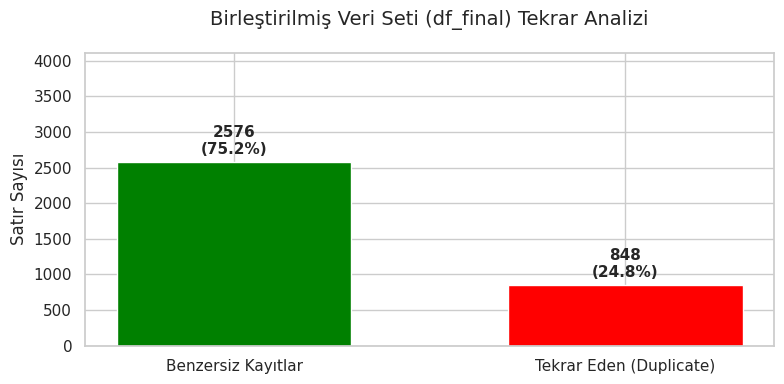

In [98]:


# df_final üzerinden verileri hesapla
total_rows = len(df_final)
duplicate_rows = df_final.duplicated().sum()
unique_rows = total_rows - duplicate_rows

# Grafik verileri ve renkleri
labels = ['Benzersiz Kayıtlar', 'Tekrar Eden (Duplicate)']
values = [unique_rows, duplicate_rows]
colors = ['Green', 'Red']

# Grafik oluşturma
plt.figure(figsize=(8, 4))
sns.set_style("whitegrid") # Daha temiz bir görünüm için

# Sütun grafiği
bars = plt.bar(labels, values, color=colors, width=0.6)

# Sayıları ve yüzdeleri sütunların üzerine yazma
for bar in bars:
    yval = bar.get_height()
    percentage = (yval / total_rows) * 100
    plt.text(bar.get_x() + bar.get_width()/2, yval + (total_rows * 0.02),
             f'{int(yval)}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Birleştirilmiş Veri Seti (df_final) Tekrar Analizi', fontsize=14, pad=20)
plt.ylabel('Satır Sayısı', fontsize=12)
plt.ylim(0, total_rows * 1.2) # Sayıların sığması için üstten pay bırak

plt.tight_layout()
plt.show()

In [ ]:
# Drop duplicate rows and report how many were removed
n_before = len(df_final)
df_final = df_final.drop_duplicates()
n_removed = n_before - len(df_final)
print(f"Removed {n_removed} duplicate rows.")
print(f"Shape after deduplication: {df_final.shape}")

## Step 2 — Outlier Detection & Handling

In [ ]:
# Cap outliers at Q1 - 1.5*IQR and Q3 + 1.5*IQR for each numeric column
capped_summary = {}
for col in df_final.select_dtypes(include='number').columns:
    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_capped = ((df_final[col] < lower) | (df_final[col] > upper)).sum()
    df_final[col] = df_final[col].clip(lower=lower, upper=upper)
    if n_capped > 0:
        capped_summary[col] = n_capped

print("Values capped per column (only columns with at least 1 capped value):")
for col, n in capped_summary.items():
    print(f"  {col}: {n}")

## Step 3 — StandardScaler (mean=0, std=1)

In [ ]:
# Apply StandardScaler to all columns
scaler = StandardScaler()
df_final = pd.DataFrame(
    scaler.fit_transform(df_final),
    columns=df_final.columns,
    index=df_final.index
)
# Confirm mean ≈ 0 and std ≈ 1 for first 5 columns
print("Mean of first 5 columns (should be ≈ 0):")
print(df_final.iloc[:, :5].mean().round(6))
print("\nStd of first 5 columns (should be ≈ 1):")
print(df_final.iloc[:, :5].std().round(6))

In [ ]:
# Final sanity checks
assert df_final.isnull().sum().sum() == 0, "❌ Nulls still present!"
assert df_final.select_dtypes(exclude='number').shape[1] == 0, "❌ Non-numeric columns present!"
print(f"✅ Final dataset ready. Shape: {df_final.shape}")
print(df_final.describe().round(3))

In [ ]:
# Save output
OUTPUT_PATH = "processed_dataset.csv"
df_final.to_csv(OUTPUT_PATH, index=False)
print(f"✅ Saved as {OUTPUT_PATH}")
print("Upload this file to: data/processed_dataset.csv in the GitHub repo.")